In [9]:
import pandas as pd
import numpy as np

In [11]:
fear_greed = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [45]:
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win,leverage
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,False,inf
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,False,0.129424
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,False,1.147739
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,False,0.996059
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,False,0.054091


In [13]:
print("Fear & Greed dataset shape:", fear_greed.shape)
print("Trades dataset shape:", trades.shape)

Fear & Greed dataset shape: (2644, 4)
Trades dataset shape: (211224, 16)


In [14]:
fear_greed.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [15]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [16]:
fear_greed.duplicated().sum()

np.int64(0)

In [17]:
trades.duplicated().sum()

np.int64(0)

In [18]:
fear_greed['date'] = pd.to_datetime(fear_greed['timestamp'], unit='s')
fear_greed['date'] = fear_greed['date'].dt.date

In [19]:
fear_greed['date'] = pd.to_datetime(fear_greed['timestamp'], unit='s')
fear_greed['date'] = fear_greed['date'].dt.date

In [20]:
print(fear_greed.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [21]:
fear_greed['date'] = pd.to_datetime(fear_greed['timestamp'], unit='s').dt.date

In [22]:
trades['date'] = pd.to_datetime(trades['Timestamp'], unit='ms').dt.date

In [23]:
print(fear_greed[['timestamp','date']].head())
print(trades[['Timestamp','date']].head())

    timestamp        date
0  1517463000  2018-02-01
1  1517549400  2018-02-02
2  1517635800  2018-02-03
3  1517722200  2018-02-04
4  1517808600  2018-02-05
      Timestamp        date
0  1.730000e+12  2024-10-27
1  1.730000e+12  2024-10-27
2  1.730000e+12  2024-10-27
3  1.730000e+12  2024-10-27
4  1.730000e+12  2024-10-27


In [24]:
merged_data = pd.merge(trades, fear_greed, on='date', how='left')

merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed


In [25]:
daily_pnl = trades.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [26]:
trades['win'] = trades['Closed PnL'] > 0

win_rate = trades['win'].mean()

print("Win Rate:", win_rate)

Win Rate: 0.4112648183918494


In [27]:
avg_trade_size = trades['Size USD'].mean()

print("Average Trade Size:", avg_trade_size)

Average Trade Size: 5639.451210373822


In [28]:
trades['leverage'] = trades['Size USD'] / trades['Start Position']

trades['leverage'].describe()

count    2.112240e+05
mean              inf
std               NaN
min     -1.045050e+10
25%     -2.710120e-02
50%      1.353705e-02
75%      6.390805e-01
max               inf
Name: leverage, dtype: float64

In [29]:
trades_per_day = trades.groupby('date').size()

trades_per_day.head()

date
2023-03-28        3
2023-11-14     1045
2024-03-09     6962
2024-07-03     7141
2024-10-27    35241
dtype: int64

In [30]:
long_short = trades['Side'].value_counts()

ratio = long_short / long_short.sum()

print(ratio)

Side
SELL    0.513805
BUY     0.486195
Name: count, dtype: float64


In [31]:
merged = pd.merge(
    trades,
    fear_greed[['date','classification','value']],
    on='date',
    how='left'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win,leverage,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,False,inf,Greed,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,False,0.129424,Greed,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,False,1.147739,Greed,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,False,0.996059,Greed,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,False,0.054091,Greed,74.0


In [34]:
def sentiment_group(x):
    if pd.isna(x):
        return "Neutral"
    if "Fear" in x:
        return "Fear"
    if "Greed" in x:
        return "Greed"
    return "Neutral"

merged['sentiment'] = merged['classification'].apply(sentiment_group)

In [35]:
pnl_by_sentiment = merged.groupby('sentiment')['Closed PnL'].mean()

pnl_by_sentiment

sentiment
Fear       50.047622
Greed      77.838247
Neutral     6.757719
Name: Closed PnL, dtype: float64

In [36]:
import os

os.makedirs("charts", exist_ok=True)

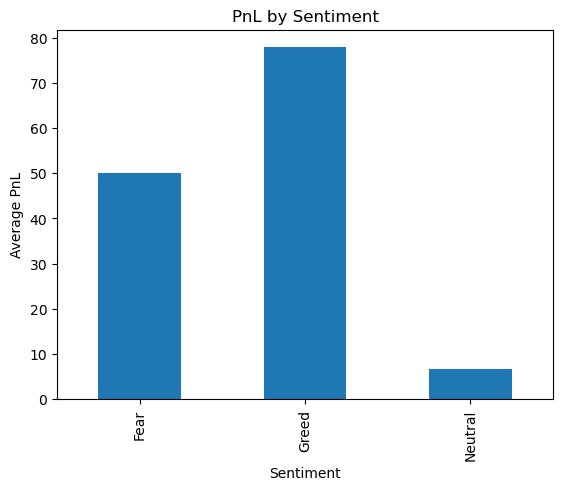

In [37]:
import matplotlib.pyplot as plt

pnl_by_sentiment.plot(kind='bar')

plt.title("PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")

plt.savefig("charts/pnl_by_sentiment.png")

plt.show()

In [39]:
plt.savefig("charts/pnl_by_sentiment.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

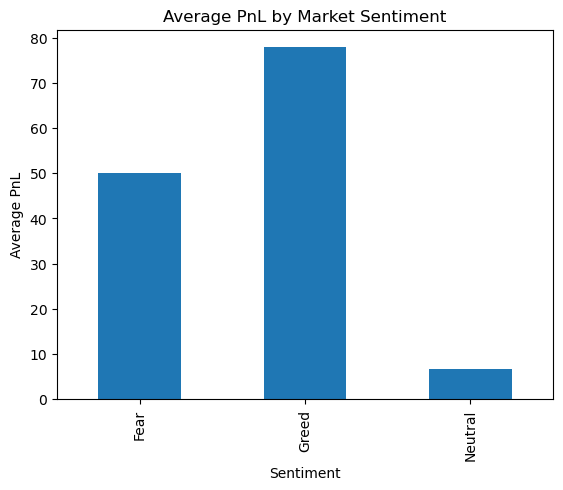

In [40]:
import os
import matplotlib.pyplot as plt

os.makedirs("charts", exist_ok=True)

pnl_by_sentiment = merged.groupby('sentiment')['Closed PnL'].mean()

pnl_by_sentiment.plot(kind='bar')

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")

plt.savefig("charts/pnl_by_sentiment.png")

plt.show()

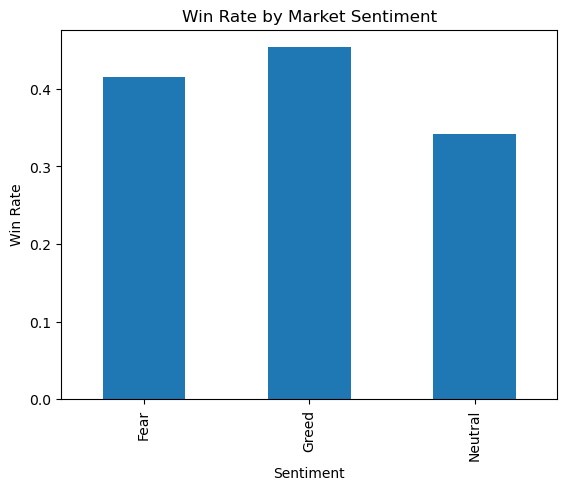

In [41]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('sentiment')['win'].mean()

win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")

plt.savefig("charts/winrate_by_sentiment.png")

plt.show()

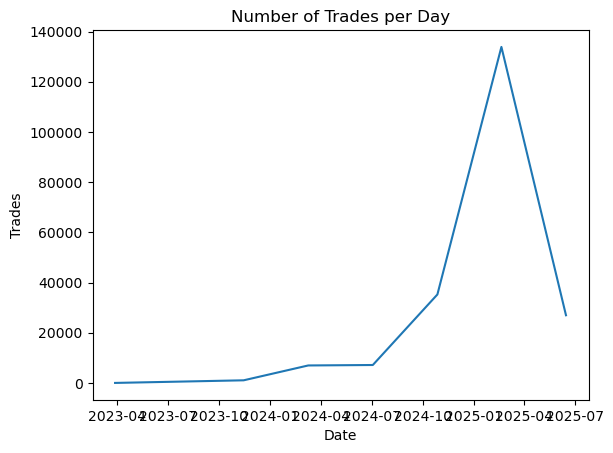

In [42]:
trades_per_day = merged.groupby('date').size()

trades_per_day.plot()

plt.title("Number of Trades per Day")
plt.xlabel("Date")
plt.ylabel("Trades")

plt.savefig("charts/trades_per_day.png")

plt.show()

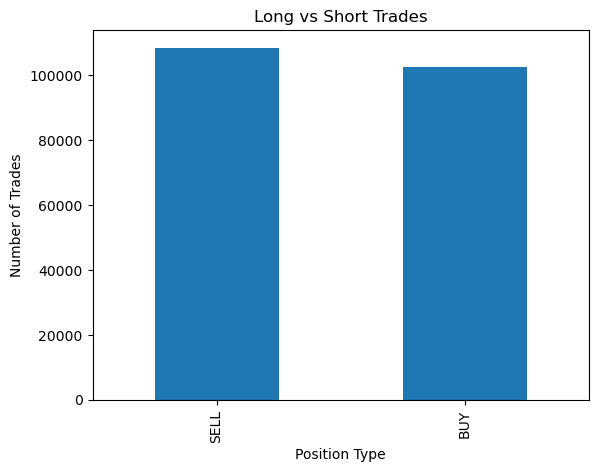

In [43]:
long_short = merged['Side'].value_counts()

long_short.plot(kind='bar')

plt.title("Long vs Short Trades")
plt.xlabel("Position Type")
plt.ylabel("Number of Trades")

plt.savefig("charts/long_short_ratio.png")

plt.show()

In [ ]:
merged['leverage'] = merged['Size USD'] / merged['Start Position']

merged['leverage'].hist(bins=30)

plt.title("Leverage Distribution")
plt.xlabel("Leverage")
plt.ylabel("Frequency")

plt.savefig("charts/leverage_distribution.png")

plt.show()